In [112]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize']=(12,8)
plt.rcParams['figure.dpi']=100

pd.set_option('display.max_columns',None)
pd.set_option('display.max_rows',100)
pd.set_option('display.float_format','{:.2f}'.format)

file_path=r'C:\Users\34883\PyCharmMiscProject\数据分析\电商行为数据.xlsx'
df=pd.read_excel(file_path,sheet_name='客户行为数据')

df.head()

,顾客ID,流失标志,使用平台时长（月）,首选登录设备,城市等级,仓库到顾客家的距离（公里）,婚姻状况,年龄分组,性别,APP使用时长（小时）,上月订单数量,订单金额较去年增长百分比,距上次下单天数,上月首选订单类别,关注的直播主数量,服务满意度评分,上月投诉情况,上月使用优惠券数量,上月平均返现金额
0,50001,流失,4.00,手机,三线城市,6.00,单身,30-39岁,女性,3.00,1.00,11.00,5.00,笔记本电脑及配件类,9,2,有,1.00,159.93
1,50002,流失,NaN,手机（可能为功能机）,一线城市,8.00,单身,40-49岁,男性,3.00,1.00,15.00,0.00,家居类,7,3,有,0.00,120.90
2,50003,流失,NaN,手机（可能为功能机）,一线城市,30.00,单身,40-49岁,男性,2.00,1.00,14.00,3.00,家居类,6,3,有,0.00,120.28
3,50004,流失,3.00,手机（可能为功能机）,三线城市,15.00,单身,40-49岁,男性,2.00,1.00,23.00,3.00,笔记本电脑及配件类,8,5,无,0.00,134.07
4,50005,流失,3.00,手机（可能为功能机）,一线城市,12.00,单身,30-39岁,男性,NaN,1.00,11.00,3.00,家居类,3,5,无,1.00,129.60


## 数据概览

数据为 5630 行 × 19 列的用户状态快照（EDA 详版见《电商数据分析.ipynb》），此处仅列关键信息。

In [113]:
print(df.shape)
df.isna().sum().sort_values(ascending=False)

(5630, 19)


距上次下单天数          307
订单金额较去年增长百分比     265
使用平台时长（月）        264
上月订单数量           258
上月使用优惠券数量        256
APP使用时长（小时）      255
仓库到顾客家的距离（公里）    251
流失标志               0
顾客ID               0
婚姻状况               0
首选登录设备             0
年龄分组               0
性别                 0
城市等级               0
上月首选订单类别           0
关注的直播主数量           0
服务满意度评分            0
上月投诉情况             0
上月平均返现金额           0
dtype: int64

## RFM分析

In [114]:
print(df['距上次下单天数'].notna().sum(),df['上月订单数量'].notna().sum(),df['上月平均返现金额'].notna().sum())

5323 5372 5630


In [115]:
df['R评分']=pd.qcut(df['距上次下单天数'],5,labels=(5,4,3,2,1))
df['R评分']=df['R评分'].fillna(1)
df['R评分'].value_counts()

R评分
4    1692
2    1326
5    1110
1    1071
3     431
Name: count, dtype: int64

In [116]:
df['M评分']=pd.qcut(df['上月平均返现金额'],5,labels=(1,2,3,4,5))
df['M评分']=df['M评分'].fillna(1)
df['M评分'].value_counts()

M评分
1    1126
2    1126
3    1126
4    1126
5    1126
Name: count, dtype: int64

In [117]:
display(df['上月订单数量'].value_counts().sort_index())
df['F评分']=pd.cut(df['上月订单数量'],bins=(0,1,2,4,8,999),labels=(1,2,3,4,5))
df['F评分']=df['F评分'].fillna(1)
df['F评分'].value_counts()

上月订单数量
1.00     1751
2.00     2025
3.00      371
4.00      204
5.00      181
6.00      137
7.00      206
8.00      172
9.00       62
10.00      36
11.00      51
12.00      54
13.00      30
14.00      36
15.00      33
16.00      23
Name: count, dtype: int64

F评分
2    2025
1    2009
4     696
3     575
5     325
Name: count, dtype: int64

In [118]:
df['R层']=np.where(df['R评分'].astype(int)>=df['R评分'].astype(int).median(),'高','低')
df['F层']=np.where(df['F评分'].astype(int)>=df['F评分'].astype(int).median(),'高','低')
df['M层']=np.where(df['M评分'].astype(int)>=df['M评分'].astype(int).median(),'高','低')
df[['R层','F层','M层']].value_counts()

R层  F层  M层
低   高   高     1465
高   高   高     1026
    低   低      951
    高   低      774
    低   高      482
低   低   高      405
    高   低      356
    低   低      171
Name: count, dtype: int64

In [119]:
df['RFM组合']=df['R层']+df['F层']+df['M层']
name_map = {
    '高高高': '重要价值客户',
    '高低高': '重要发展客户',
    '低高高': '重要保持客户',
    '低低高': '重要挽留客户',
    '高高低': '一般价值客户',
    '高低低': '一般发展客户',
    '低高低': '一般保持客户',
    '低低低': '一般挽留客户'
}
df['用户分层']=df['RFM组合'].map(name_map)
df['用户分层'].value_counts()

用户分层
重要保持客户    1465
重要价值客户    1026
一般发展客户     951
一般价值客户     774
重要发展客户     482
重要挽留客户     405
一般保持客户     356
一般挽留客户     171
Name: count, dtype: int64

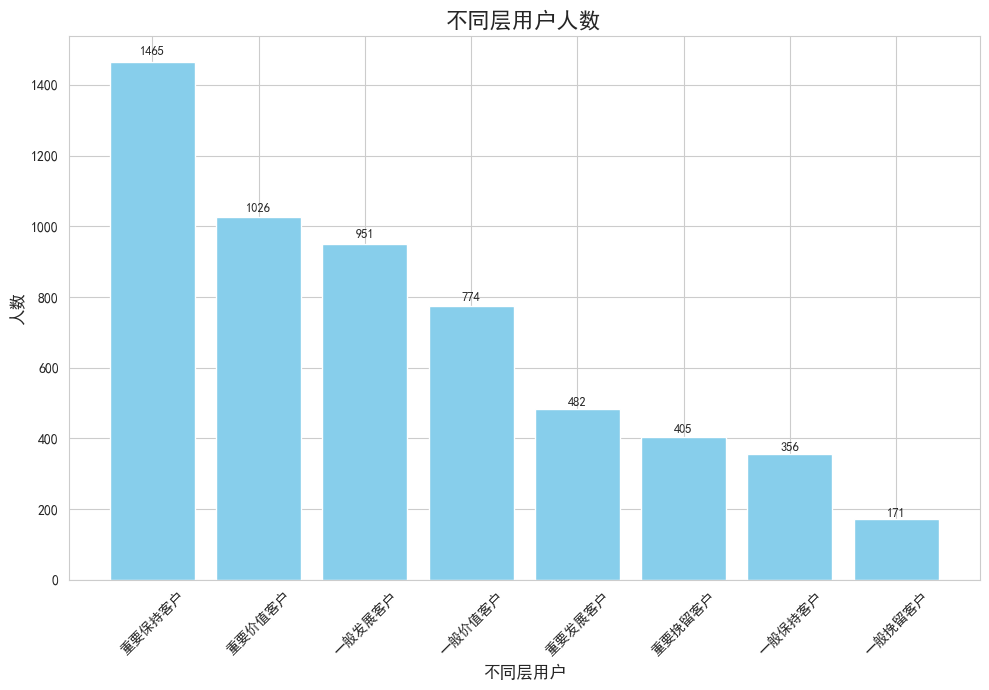

In [120]:
fig,axes=plt.subplots(figsize=(10,7))
plt.rcParams['font.sans-serif']=['SimHei']
plt.rcParams['axes.unicode_minus']=False
counts=df['用户分层'].value_counts()
axes.bar(counts.index,counts.values,color='skyblue')
axes.set_title('不同层用户人数',fontsize=16,fontweight='bold')
axes.set_xlabel('不同层用户',fontsize=12)
axes.set_ylabel('人数',fontsize=12)
axes.tick_params('x',rotation=45)
for i,v in enumerate(counts.values):
    axes.text(i,v*1.01,str(v),ha='center',va='bottom',fontsize=9)
plt.tight_layout()
plt.show()

In [121]:
df['流失标志'].value_counts(normalize=True)

流失标志
未流失   0.83
流失    0.17
Name: proportion, dtype: float64

In [122]:
churn=pd.crosstab(df['用户分层'],df['流失标志'],normalize='index')
display(churn)
churned=churn['流失']

流失标志,未流失,流失
用户分层,,
一般价值客户,0.71,0.29
一般保持客户,0.81,0.19
一般发展客户,0.74,0.26
一般挽留客户,0.92,0.08
重要价值客户,0.86,0.14
重要保持客户,0.88,0.12
重要发展客户,0.90,0.10
重要挽留客户,0.93,0.07


In [123]:
pd.crosstab(df['用户分层'],df['流失标志'])

流失标志,未流失,流失
用户分层,,
一般价值客户,546,228
一般保持客户,290,66
一般发展客户,707,244
一般挽留客户,157,14
重要价值客户,882,144
重要保持客户,1289,176
重要发展客户,436,46
重要挽留客户,375,30


### 交叉发现：
消费水平（M）是用户流失的最强分层信号：
低消费群体的流失率普遍高于大盘 17%，其中‘低消费但高活跃’的一般价值客户流失率达 29%，接近基线两倍；
高消费群体则全部低于基线，最粘性的重要挽留客户仅 7%。
建议将运营资源从‘挽回沉睡高价值用户’转向‘提升低消费活跃用户的客单价’。


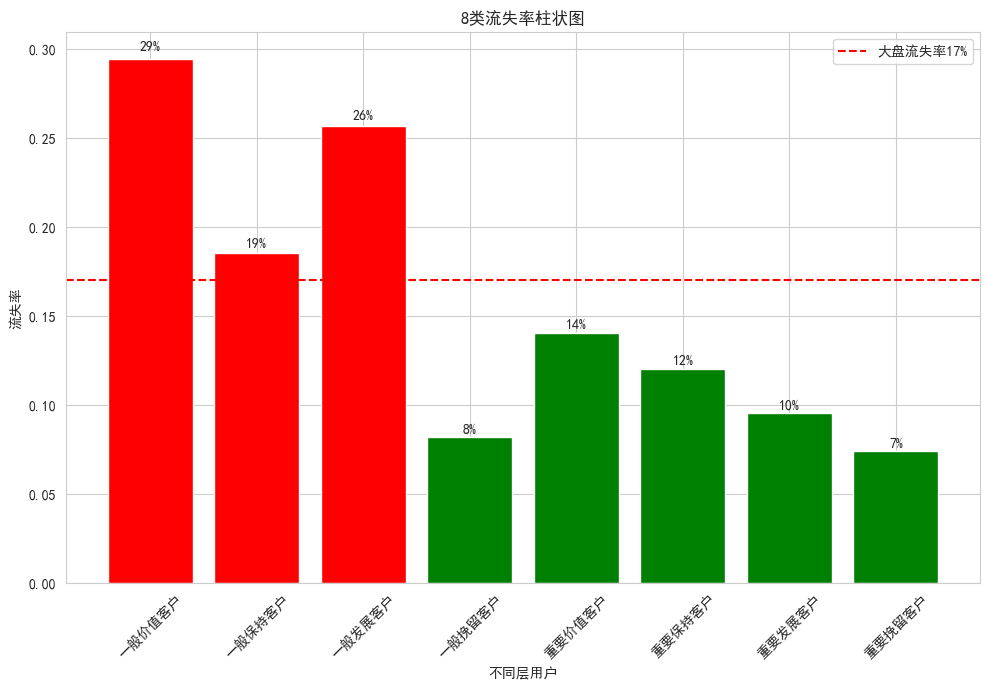

In [124]:
fig,axes=plt.subplots(figsize=(10,7))
colors=['red' if v>0.17 else 'green' for v in churned.values]
axes.bar(churned.index,churned.values,color=colors)
axes.set_title('8类流失率柱状图',fontsize=12)
axes.set_xlabel('不同层用户',fontsize=10)
axes.set_ylabel('流失率',fontsize=10)
axes.tick_params('x',rotation=45)
for i,v in enumerate(churned.values):
    axes.text(i,v*1.01,f'{v:.0%}',ha='center',va='bottom')
plt.axhline(0.17,color='red',linestyle='--',linewidth=1.5,label='大盘流失率17%')
plt.legend()
plt.tight_layout()
plt.show()

## 漏斗分析

In [125]:
# 划分层级
df_all=df.copy()
s1=df_all                                          ##全体用户
s2=s1[s1['上月订单数量']>0]                          #上月有下单用户
s3=s2[s2['上月订单数量']>=2]                         # 上月复购用户
threshold=df_all['上月平均返现金额'].quantile(0.8)
s4=s3[s3['上月平均返现金额']>=threshold]              # 高价值用户
print(len(s1),len(s2),len(s3),len(s4))

5630 5372 3621 734


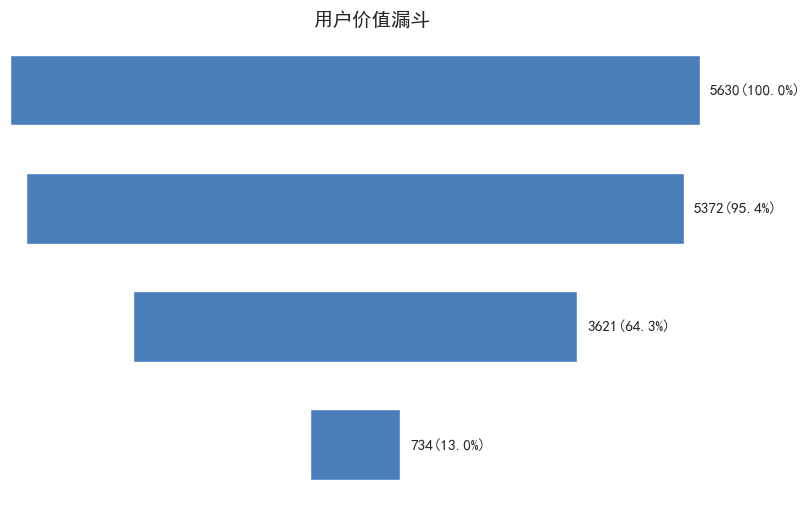

In [126]:
# 漏斗可视化

# 准备数据
labels=['全体用户','上月有单','复购用户','高价值客户']
vals=[len(s1),len(s2),len(s3),len(s4)]
# 算每个条左边要空多长
total=vals[0]
left=[(total-v)/2 for v in vals]
# 画横向条形图
# barh的y轴是自下往上画的 第一条画最下面
# constrained_layout是plt.tight_layout()的proplus版
fig,axes=plt.subplots(figsize=(8,5),constrained_layout=True)
axes.barh(labels[::-1],vals[::-1],left=left[::-1],color='#4a7ebb',height=0.6)
# 贴标签＋关坐标轴
for i,v in enumerate(vals[::-1]):
    # ha，va分别代表水平对齐和垂直对齐
    axes.text((total+v)/2+total*0.015,i,f'{v}({v/total:.1%})',ha='left',va='center',fontsize=11)
axes.set_title('用户价值漏斗',fontsize=14)
axes.axis('off')
# 关掉坐标轴所有装饰
plt.show()

In [127]:
s4['流失标志'].value_counts(normalize=True)

流失标志
未流失   0.89
流失    0.11
Name: proportion, dtype: float64

# 项目结论
## 一、背景
数据为5630名用户×19个字段的状态快照，无浏览、加购等事件流水。
分析目标：识别高价值用户、定位流失信号，为用户运营提供依据
## 二、方法
本项目采用RFM八类分层和漏斗分层分析方法。漏斗四层分别指代全体用户、上月有订单用户、上月有复购用户、高价值用户。由于R中位数仅3天，无法切割出活跃用户与沉睡用户，故在漏斗第三层（L3）改用复购层。R缺失的307人全部上月有订单，属记录缺失而非未下单；且全体用户均有下单证据，历史下单层无区分价值，故不设此层。
## 三、发现
在漏斗中，各层用户自上而下数量分别为5630、5372、3621、734，复购客户占比和高价值客户占比分别为64.3%与13.0%。在RFM八类分层中发现M是流失最强信号，相较于大盘流失率17%，低M流失率最高达29%。此外，流失组R均值3.2小于未流失组4.8。高价值客户流失率为10.6%，低于大盘的16.8%，与M信号互证。
## 四、建议与局限
**建议**：
- 圈出78个高价值流失用户，优先单独挽留
- 针对1750个上月仅1单的用户做复购激活

**局限**：
- 流失组R均值3.2低于未流失组4.8，流失标志疑为“预警”而非“已流失”口径，需与业务方确认
- 快照数据无事件流水，无法分析浏览→下单的行为路径